 Load the SMS Spam Collection dataset using Pandas.

In [26]:
import pandas as pd
df=pd.read_csv("spam.csv",encoding='cp1252')
df

,v1,v2,Unnamed: 2,Unnamed: 3,Unnamed: 4
0,ham,"Go until jurong point, crazy.. Available only ...",NaN,NaN,NaN
1,ham,Ok lar... Joking wif u oni...,NaN,NaN,NaN
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...,NaN,NaN,NaN
3,ham,U dun say so early hor... U c already then say...,NaN,NaN,NaN
4,ham,"Nah I don't think he goes to usf, he lives aro...",NaN,NaN,NaN
...,...,...,...,...,...
5567,spam,This is the 2nd time we have tried 2 contact u...,NaN,NaN,NaN
5568,ham,Will Ì_ b going to esplanade fr home?,NaN,NaN,NaN
5569,ham,"Pity, * was in mood for that. So...any other s...",NaN,NaN,NaN
5570,ham,The guy did some bitching but I acted like i'd...,NaN,NaN,NaN


 Display dataset shape, columns, and sample records.  

In [27]:
df.shape

(5572, 5)

In [28]:
df.columns

Index(['v1', 'v2', 'Unnamed: 2', 'Unnamed: 3', 'Unnamed: 4'], dtype='object')

Check the distribution of spam and ham messages  

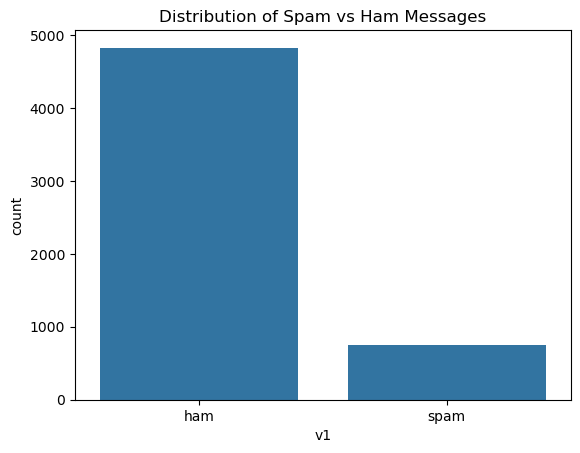

In [29]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.countplot(x='v1', data=df)
plt.title("Distribution of Spam vs Ham Messages")
plt.show()

Rename columns if required.  

In [30]:
df.rename(columns={"v1":"class_label","v2":"message"},inplace=True)
df

,class_label,message,Unnamed: 2,Unnamed: 3,Unnamed: 4
0,ham,"Go until jurong point, crazy.. Available only ...",NaN,NaN,NaN
1,ham,Ok lar... Joking wif u oni...,NaN,NaN,NaN
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...,NaN,NaN,NaN
3,ham,U dun say so early hor... U c already then say...,NaN,NaN,NaN
4,ham,"Nah I don't think he goes to usf, he lives aro...",NaN,NaN,NaN
...,...,...,...,...,...
5567,spam,This is the 2nd time we have tried 2 contact u...,NaN,NaN,NaN
5568,ham,Will Ì_ b going to esplanade fr home?,NaN,NaN,NaN
5569,ham,"Pity, * was in mood for that. So...any other s...",NaN,NaN,NaN
5570,ham,The guy did some bitching but I acted like i'd...,NaN,NaN,NaN


Remove unwanted or duplicate records

In [31]:
df.drop(['Unnamed: 2','Unnamed: 3','Unnamed: 4'],axis=1,inplace=True)
df

,class_label,message
0,ham,"Go until jurong point, crazy.. Available only ..."
1,ham,Ok lar... Joking wif u oni...
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...
3,ham,U dun say so early hor... U c already then say...
4,ham,"Nah I don't think he goes to usf, he lives aro..."
...,...,...
5567,spam,This is the 2nd time we have tried 2 contact u...
5568,ham,Will Ì_ b going to esplanade fr home?
5569,ham,"Pity, * was in mood for that. So...any other s..."
5570,ham,The guy did some bitching but I acted like i'd...


Convert class labels into numeric format

In [32]:
df["class_label"]=df["class_label"].apply(lambda x:1 if x=="spam" else 0)
df

,class_label,message
0,0,"Go until jurong point, crazy.. Available only ..."
1,0,Ok lar... Joking wif u oni...
2,1,Free entry in 2 a wkly comp to win FA Cup fina...
3,0,U dun say so early hor... U c already then say...
4,0,"Nah I don't think he goes to usf, he lives aro..."
...,...,...
5567,1,This is the 2nd time we have tried 2 contact u...
5568,0,Will Ì_ b going to esplanade fr home?
5569,0,"Pity, * was in mood for that. So...any other s..."
5570,0,The guy did some bitching but I acted like i'd...


3: Text Preprocessing 

Convert text to lowercase.  

In [34]:
df['message'] = df['message'].str.lower()
df

,class_label,message
0,0,"go until jurong point, crazy.. available only ..."
1,0,ok lar... joking wif u oni...
2,1,free entry in 2 a wkly comp to win fa cup fina...
3,0,u dun say so early hor... u c already then say...
4,0,"nah i don't think he goes to usf, he lives aro..."
...,...,...
5567,1,this is the 2nd time we have tried 2 contact u...
5568,0,will ì_ b going to esplanade fr home?
5569,0,"pity, * was in mood for that. so...any other s..."
5570,0,the guy did some bitching but i acted like i'd...


In [36]:
import re
df['message'] = df['message'].apply(lambda x: re.sub(r'[^a-zA-Z0-9\s]', '', x))
df

,class_label,message
0,0,go until jurong point crazy available only in ...
1,0,ok lar joking wif u oni
2,1,free entry in 2 a wkly comp to win fa cup fina...
3,0,u dun say so early hor u c already then say
4,0,nah i dont think he goes to usf he lives aroun...
...,...,...
5567,1,this is the 2nd time we have tried 2 contact u...
5568,0,will b going to esplanade fr home
5569,0,pity was in mood for that soany other suggest...
5570,0,the guy did some bitching but i acted like id ...


Remove numbers.  

In [37]:
df['message'] = df['message'].apply(lambda x: re.sub(r'\d+', '', x))
df

,class_label,message
0,0,go until jurong point crazy available only in ...
1,0,ok lar joking wif u oni
2,1,free entry in a wkly comp to win fa cup final...
3,0,u dun say so early hor u c already then say
4,0,nah i dont think he goes to usf he lives aroun...
...,...,...
5567,1,this is the nd time we have tried contact u u...
5568,0,will b going to esplanade fr home
5569,0,pity was in mood for that soany other suggest...
5570,0,the guy did some bitching but i acted like id ...


Perform tokenization.

In [40]:
df['message'] = df['message'].apply(lambda x:x.split())
df

,class_label,message
0,0,"[go, until, jurong, point, crazy, available, o..."
1,0,"[ok, lar, joking, wif, u, oni]"
2,1,"[free, entry, in, a, wkly, comp, to, win, fa, ..."
3,0,"[u, dun, say, so, early, hor, u, c, already, t..."
4,0,"[nah, i, dont, think, he, goes, to, usf, he, l..."
...,...,...
5567,1,"[this, is, the, nd, time, we, have, tried, con..."
5568,0,"[will, b, going, to, esplanade, fr, home]"
5569,0,"[pity, was, in, mood, for, that, soany, other,..."
5570,0,"[the, guy, did, some, bitching, but, i, acted,..."


In [60]:
df['message'] = df['message'].apply(lambda x: " ".join(x))

In [61]:
from sklearn.feature_extraction.text import CountVectorizer
vectorizer = CountVectorizer(lowercase=True,stop_words='english')


4: Train-Test Split

In [62]:
from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test=train_test_split(df["message"],df["class_label"],test_size=0.3,random_state=0)
y_train.value_counts()
y_test.value_counts()

class_label
0    1434
1     238
Name: count, dtype: int64

In [63]:
print(type(df['message'].iloc[0]))


<class 'str'>


In [64]:
from sklearn.feature_extraction.text import CountVectorizer
vectorizer=CountVectorizer(stop_words="english")
x_train_trans=vectorizer.fit_transform(x_train)
x_test_trans=vectorizer.transform(x_test)

In [65]:
x_train_trans

<Compressed Sparse Row sparse matrix of dtype 'int64'
	with 28604 stored elements and shape (3900, 6667)>

In [66]:
x_train_trans.toarray()

array([[0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       ...,
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0]], shape=(3900, 6667))

In [67]:
vectorizer.get_feature_names_out()

array(['aa', 'aah', 'aaniye', ..., 'zindgi', 'zouk', 'zyada'],
      shape=(6667,), dtype=object)

5: Model Building 

 Train a Multinomial Naive Bayes classifier

In [68]:
 from sklearn.naive_bayes import MultinomialNB

In [69]:
classifier=MultinomialNB()
classifier.fit(x_train_trans,y_train)

,alpha,1.0
,force_alpha,True
,fit_prior,True
,class_prior,None


In [70]:
y_pred=classifier.predict(x_test_trans)
y_pred

array([0, 0, 0, ..., 0, 0, 0], shape=(1672,))

In [71]:
y_test.count()
y_test
y_pred

array([0, 0, 0, ..., 0, 0, 0], shape=(1672,))

6: Model Evaluation 

 Accuracy Score  
 Confusion Matrix  
 Precision  
 Recall  
 F1-Score  
 Classification Report  

In [72]:
from sklearn.metrics  import accuracy_score,classification_report,confusion_matrix

In [75]:
print(accuracy_score(y_test,y_pred))

0.9832535885167464


In [77]:
print(confusion_matrix(y_test,y_pred))

[[1425    9]
 [  19  219]]


In [76]:
print(classification_report(y_test,y_pred))

              precision    recall  f1-score   support

           0       0.99      0.99      0.99      1434
           1       0.96      0.92      0.94       238

    accuracy                           0.98      1672
   macro avg       0.97      0.96      0.97      1672
weighted avg       0.98      0.98      0.98      1672



7: Prediction on New Messages 

In [78]:
new_email="congratulation you win redmiTv"
new_email_trans=vectorizer.transform([new_email])
new_email_trans

<Compressed Sparse Row sparse matrix of dtype 'int64'
	with 1 stored elements and shape (1, 6667)>

In [79]:
new_email_trans.toarray()

array([[0, 0, 0, ..., 0, 0, 0]], shape=(1, 6667))

In [80]:
classifier.predict(new_email_trans)

array([1])

8: Laplace Smoothing

In [95]:
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import accuracy_score

nb_no_smoothing = MultinomialNB(alpha=0)

nb_no_smoothing.fit(x_train_trans, y_train)

y_pred1 = nb_no_smoothing.predict(x_test_trans)

acc1 = accuracy_score(y_test, y_pred1)

print("Accuracy without Laplace Smoothing:", acc1)

Accuracy without Laplace Smoothing: 0.9497607655502392


C:\Users\Acer\anaconda3\Lib\site-packages\sklearn\naive_bayes.py:898: RuntimeWarning: divide by zero encountered in log
  self.feature_log_prob_ = np.log(smoothed_fc) - np.log(


In [96]:
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import accuracy_score

nb_no_smoothing = MultinomialNB(alpha=1)

nb_no_smoothing.fit(x_train_trans, y_train)

y_pred1 = nb_no_smoothing.predict(x_test_trans)

acc2 = accuracy_score(y_test, y_pred1)

print("Accuracy without Laplace Smoothing:", acc2)

Accuracy without Laplace Smoothing: 0.9832535885167464


In [97]:
print("Without Smoothing Accuracy :", acc1)
print("With Smoothing Accuracy    :", acc2)

Without Smoothing Accuracy : 0.9497607655502392
With Smoothing Accuracy    : 0.9832535885167464
